In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import copy
from PIL import Image
import gc

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torchvision import models, transforms

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report
)

import warnings
warnings.filterwarnings('ignore')

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

# Set random seeds for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print('Libraries imported successfully')

Using device: cuda
GPU: Tesla P100-PCIE-16GB
Libraries imported successfully


In [2]:
# Load preprocessed data
print('Loading preprocessed data...')

DATA_PATH = '/kaggle/input/brain-tumor-mri-preprocess-sets/'

# Load train set (augmented)
train_images = np.load(os.path.join(DATA_PATH, 'preprocessed_train_images.npy'), mmap_mode='r')
train_labels = np.load(os.path.join(DATA_PATH, 'preprocessed_train_labels.npy'))

# Load validation set (original, not augmented)
val_images = np.load(os.path.join(DATA_PATH, 'preprocessed_val_images.npy'), mmap_mode='r')
val_labels = np.load(os.path.join(DATA_PATH, 'preprocessed_val_labels.npy'))

# Load test set (original, not augmented)
test_images = np.load(os.path.join(DATA_PATH, 'preprocessed_test_images.npy'), mmap_mode='r')
test_labels = np.load(os.path.join(DATA_PATH, 'preprocessed_test_labels.npy'))

# Load class names
label_classes = np.load(os.path.join(DATA_PATH, 'label_classes.npy'))

print('Preprocessed data loaded successfully!')
print(f'\nTrain set: {len(train_images)} images, shape: {train_images[0].shape}')
print(f'Validation set: {len(val_images)} images, shape: {val_images[0].shape}')
print(f'Test set: {len(test_images)} images, shape: {test_images[0].shape}')

# Check class distribution
print('\nClass distribution:')
print(f'Classes: {label_classes}')

Loading preprocessed data...
Preprocessed data loaded successfully!

Train set: 22845 images, shape: (256, 256, 3)
Validation set: 1143 images, shape: (256, 256, 3)
Test set: 1311 images, shape: (256, 256, 3)

Class distribution:
Classes: ['glioma_tumor' 'meningioma_tumor' 'no_tumor' 'pituitary_tumor']


In [3]:
# Use actual labels from data:
label_classes = np.unique(np.concatenate([train_labels, val_labels, test_labels]))
label_classes = np.sort(label_classes)

print(f'Using actual classes: {label_classes}')

label_encoder = LabelEncoder()
label_encoder.classes_ = label_classes

Using actual classes: ['glioma' 'meningioma' 'notumor' 'pituitary']


In [4]:
# # Create label encoder using the saved classes
# label_encoder = LabelEncoder()
# label_encoder.classes_ = label_classes

# Encode labels (they're already strings from preprocessing)
train_labels_encoded = label_encoder.transform(train_labels)
val_labels_encoded = label_encoder.transform(val_labels)
test_labels_encoded = label_encoder.transform(test_labels)

# Create label mapping for reference
label_mapping = {i: label for i, label in enumerate(label_encoder.classes_)}
print('\nLabel mapping:')
for idx, class_name in label_mapping.items():
    print(f'{idx}: {class_name}')

# Store class names for later use
class_names = label_encoder.classes_
num_classes = len(class_names)
print(f'\nNumber of classes: {num_classes}')


Label mapping:
0: glioma
1: meningioma
2: notumor
3: pituitary

Number of classes: 4


In [5]:
# Verify data distribution (already split in preprocessing)
print('\nTraining set distribution:')
unique, counts = np.unique(train_labels_encoded, return_counts=True)
for label, count in zip(unique, counts):
    print(f'{label_mapping[label]}: {count} images')

print('\nValidation set distribution:')
unique, counts = np.unique(val_labels_encoded, return_counts=True)
for label, count in zip(unique, counts):
    print(f'{label_mapping[label]}: {count} images')

print('\nTest set distribution:')
unique, counts = np.unique(test_labels_encoded, return_counts=True)
for label, count in zip(unique, counts):
    print(f'{label_mapping[label]}: {count} images')


Training set distribution:
glioma: 5285 images
meningioma: 5355 images
notumor: 6380 images
pituitary: 5825 images

Validation set distribution:
glioma: 264 images
meningioma: 268 images
notumor: 319 images
pituitary: 292 images

Test set distribution:
glioma: 300 images
meningioma: 306 images
notumor: 405 images
pituitary: 300 images


In [6]:
class BrainTumorDataset(Dataset):
    """
    Custom dataset that loads images on-the-fly from memory-mapped array
    Images are already preprocessed to 256x256 with gamma correction
    Only needs to resize if model requires different input size
    """
    def __init__(self, images_mmap, labels, input_size=256):
        self.images_mmap = images_mmap
        self.labels = labels
        self.input_size = input_size
        self.needs_resize = (input_size != 256)
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        # Load image from memory-mapped array
        image = self.images_mmap[idx].copy()
        label = self.labels[idx]
        
        # Images are already gamma corrected and in range 0-255
        # Normalize to 0-1
        image = image.astype(np.float32) / 255.0
        
        # Convert BGR to RGB
        image = image[:, :, [2, 1, 0]]
        
        # Resize only if model requires different size
        if self.needs_resize:
            image_pil = Image.fromarray((image * 255).astype(np.uint8))
            image_pil = image_pil.resize((self.input_size, self.input_size), Image.LANCZOS)
            image = np.array(image_pil).astype(np.float32) / 255.0
        
        # Convert to tensor and permute to (C, H, W)
        image_tensor = torch.from_numpy(image).permute(2, 0, 1)
        
        # Apply ImageNet normalization
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        image_tensor = (image_tensor - mean) / std
        
        label_tensor = torch.tensor(label, dtype=torch.long)
        
        return image_tensor, label_tensor

print('Custom Dataset class defined')

Custom Dataset class defined


In [7]:
INPUT_SIZE = 224

print(f'Creating datasets with input size: {INPUT_SIZE}x{INPUT_SIZE}...')

# Create datasets directly (no indices needed - data already split!)
train_dataset = BrainTumorDataset(train_images, train_labels_encoded, input_size=INPUT_SIZE)
val_dataset = BrainTumorDataset(val_images, val_labels_encoded, input_size=INPUT_SIZE)
test_dataset = BrainTumorDataset(test_images, test_labels_encoded, input_size=INPUT_SIZE)

print('Datasets created successfully')
print(f'Train dataset: {len(train_dataset)} images')
print(f'Val dataset: {len(val_dataset)} images')
print(f'Test dataset: {len(test_dataset)} images')

Creating datasets with input size: 224x224...
Datasets created successfully
Train dataset: 22845 images
Val dataset: 1143 images
Test dataset: 1311 images


In [8]:
# Create dataloaders
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, 
                         num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                       num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                        num_workers=2, pin_memory=True)

print('DataLoaders created')
print(f'Batch size: {BATCH_SIZE}')
print(f'Training batches: {len(train_loader)}')
print(f'Validation batches: {len(val_loader)}')
print(f'Test batches: {len(test_loader)}')

# Test loading one batch to verify everything works
print('\nTesting data loading...')
test_batch = next(iter(train_loader))
print(f'Batch images shape: {test_batch[0].shape}')
print(f'Batch labels shape: {test_batch[1].shape}')
print('Data loading test successful!')

DataLoaders created
Batch size: 32
Training batches: 714
Validation batches: 36
Test batches: 41

Testing data loading...
Batch images shape: torch.Size([32, 3, 224, 224])
Batch labels shape: torch.Size([32])
Data loading test successful!


In [9]:
def create_resnet50_model(num_classes, pretrained=True):
    """
    Create ResNet50 model with custom classifier head
    """
    model = models.resnet50(pretrained=pretrained)
    
    # Replace final fully connected layer with custom head
    num_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(num_features, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, num_classes)
    )
    
    return model

# Create model
model = create_resnet50_model(num_classes=num_classes, pretrained=True)
model = model.to(device)

print('ResNet50 model created successfully')
print(f'Model moved to {device}')

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'Total parameters: {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 159MB/s]


ResNet50 model created successfully
Model moved to cuda
Total parameters: 24,033,604
Trainable parameters: 24,033,604


In [10]:
# Training hyperparameters
NUM_EPOCHS_PHASE1 = 20
NUM_EPOCHS_PHASE2 = 30
LEARNING_RATE_PHASE1 = 0.001
LEARNING_RATE_PHASE2 = 0.0001
EARLY_STOPPING_PATIENCE = 7

# Loss function
criterion = nn.CrossEntropyLoss()

# Training history
history = {
    'phase': [],
    'epoch': [],
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'lr': []
}

# Early stopping setup
best_val_loss = float('inf')
patience_counter = 0
best_model_wts = None

print('Training configuration:')
print(f'Phase 1 epochs: {NUM_EPOCHS_PHASE1}')
print(f'Phase 2 epochs: {NUM_EPOCHS_PHASE2}')
print(f'Phase 1 learning rate: {LEARNING_RATE_PHASE1}')
print(f'Phase 2 learning rate: {LEARNING_RATE_PHASE2}')
print(f'Early stopping patience: {EARLY_STOPPING_PATIENCE}')

Training configuration:
Phase 1 epochs: 20
Phase 2 epochs: 30
Phase 1 learning rate: 0.001
Phase 2 learning rate: 0.0001
Early stopping patience: 7


In [11]:
def freeze_backbone(model):
    """
    Freeze all layers except the final classifier
    """
    for name, param in model.named_parameters():
        if 'fc' not in name:
            param.requires_grad = False
    
    return model

def unfreeze_all(model):
    """
    Unfreeze all layers for fine-tuning
    """
    for param in model.parameters():
        param.requires_grad = True
    
    return model

def set_batchnorm_eval(model):
    """
    Set all BatchNorm layers to evaluation mode
    """
    for module in model.modules():
        if isinstance(module, nn.BatchNorm2d):
            module.eval()

def train_epoch(model, train_loader, criterion, optimizer, device, phase='phase1'):
    """
    Train for one epoch
    """
    model.train()
    
    # Keep BatchNorm in eval mode during phase 2
    if phase == 'phase2':
        set_batchnorm_eval(model)
    
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    
    return epoch_loss, epoch_acc

def validate_epoch(model, val_loader, criterion, device):
    """
    Validate for one epoch
    """
    model.eval()
    
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    
    return epoch_loss, epoch_acc

print('Training helper functions defined')

Training helper functions defined


In [12]:
print('Starting Phase 1: Training with frozen backbone')
print(f'Epochs: {NUM_EPOCHS_PHASE1}, Learning Rate: {LEARNING_RATE_PHASE1}')
print()

# Freeze backbone
model = freeze_backbone(model)

# Count trainable parameters
trainable_params_phase1 = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters in Phase 1: {trainable_params_phase1:,}')
print()

# Optimizer and scheduler
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), 
                        lr=LEARNING_RATE_PHASE1, weight_decay=0.01)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', 
                                                   factor=0.5, patience=3)

# Training loop for Phase 1
for epoch in range(NUM_EPOCHS_PHASE1):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device, phase='phase1')
    val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)
    
    # Get current learning rate
    current_lr = optimizer.param_groups[0]['lr']
    
    # Step scheduler
    old_lr = current_lr
    scheduler.step(val_loss)
    new_lr = optimizer.param_groups[0]['lr']
    
    if new_lr != old_lr:
        print(f'Learning rate reduced from {old_lr:.6f} to {new_lr:.6f}')
    
    # Store history
    history['phase'].append(1)
    history['epoch'].append(epoch + 1)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['lr'].append(new_lr)
    
    print(f'Phase 1 - Epoch {epoch+1}/{NUM_EPOCHS_PHASE1}')
    print(f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}')
    print(f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')
    print(f'Learning Rate: {new_lr:.6f}')
    
    # Early stopping check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_wts = copy.deepcopy(model.state_dict())
        print('Validation loss improved. Saving model...')
    else:
        patience_counter += 1
        print(f'No improvement in validation loss. Patience: {patience_counter}/{EARLY_STOPPING_PATIENCE}')
    
    print()
    
    if patience_counter >= EARLY_STOPPING_PATIENCE:
        print(f'Early stopping triggered at epoch {epoch+1}')
        break

print('Phase 1 training completed')
print()

Starting Phase 1: Training with frozen backbone
Epochs: 20, Learning Rate: 0.001

Trainable parameters in Phase 1: 525,572

Phase 1 - Epoch 1/20
Train Loss: 0.5370, Train Acc: 0.7910
Val Loss: 0.3233, Val Acc: 0.9003
Learning Rate: 0.001000
Validation loss improved. Saving model...

Phase 1 - Epoch 2/20
Train Loss: 0.4434, Train Acc: 0.8318
Val Loss: 0.2848, Val Acc: 0.8994
Learning Rate: 0.001000
Validation loss improved. Saving model...

Phase 1 - Epoch 3/20
Train Loss: 0.4070, Train Acc: 0.8439
Val Loss: 0.2941, Val Acc: 0.8950
Learning Rate: 0.001000
No improvement in validation loss. Patience: 1/7

Phase 1 - Epoch 4/20
Train Loss: 0.3984, Train Acc: 0.8463
Val Loss: 0.3147, Val Acc: 0.8810
Learning Rate: 0.001000
No improvement in validation loss. Patience: 2/7

Phase 1 - Epoch 5/20
Train Loss: 0.3815, Train Acc: 0.8530
Val Loss: 0.2680, Val Acc: 0.9073
Learning Rate: 0.001000
Validation loss improved. Saving model...

Phase 1 - Epoch 6/20
Train Loss: 0.3744, Train Acc: 0.8549
Val

In [13]:
print('Starting Phase 2: Fine-tuning entire network')
print(f'Epochs: {NUM_EPOCHS_PHASE2}, Learning Rate: {LEARNING_RATE_PHASE2}')
print()

# Unfreeze all layers
model = unfreeze_all(model)

# Count trainable parameters
trainable_params_phase2 = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters in Phase 2: {trainable_params_phase2:,}')
print()

# New optimizer and scheduler for Phase 2
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE_PHASE2, weight_decay=0.05)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', 
                                                   factor=0.5, patience=3)

# Get number of epochs completed in Phase 1
phase1_epochs = len([x for x in history['phase'] if x == 1])

# Training loop for Phase 2
for epoch in range(NUM_EPOCHS_PHASE2):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device, phase='phase2')
    val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)
    
    # Get current learning rate
    current_lr = optimizer.param_groups[0]['lr']
    
    # Step scheduler
    old_lr = current_lr
    scheduler.step(val_loss)
    new_lr = optimizer.param_groups[0]['lr']
    
    if new_lr != old_lr:
        print(f'Learning rate reduced from {old_lr:.6f} to {new_lr:.6f}')
    
    # Store history
    history['phase'].append(2)
    history['epoch'].append(phase1_epochs + epoch + 1)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['lr'].append(new_lr)
    
    print(f'Phase 2 - Epoch {epoch+1}/{NUM_EPOCHS_PHASE2} (Total: {phase1_epochs + epoch + 1})')
    print(f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}')
    print(f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')
    print(f'Learning Rate: {new_lr:.6f}')
    
    # Early stopping check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_wts = copy.deepcopy(model.state_dict())
        print('Validation loss improved. Saving model...')
    else:
        patience_counter += 1
        print(f'No improvement in validation loss. Patience: {patience_counter}/{EARLY_STOPPING_PATIENCE}')
    
    print()
    
    if patience_counter >= EARLY_STOPPING_PATIENCE:
        print(f'Early stopping triggered at epoch {phase1_epochs + epoch + 1}')
        break

# Load best model weights
if best_model_wts is not None:
    model.load_state_dict(best_model_wts)
    print('Loaded best model weights')

print('Training completed')

Starting Phase 2: Fine-tuning entire network
Epochs: 30, Learning Rate: 0.0001

Trainable parameters in Phase 2: 24,033,604

Phase 2 - Epoch 1/30 (Total: 21)
Train Loss: 0.3380, Train Acc: 0.8949
Val Loss: 0.1549, Val Acc: 0.9458
Learning Rate: 0.000100
Validation loss improved. Saving model...

Phase 2 - Epoch 2/30 (Total: 22)
Train Loss: 0.0879, Train Acc: 0.9708
Val Loss: 0.0705, Val Acc: 0.9816
Learning Rate: 0.000100
Validation loss improved. Saving model...

Phase 2 - Epoch 3/30 (Total: 23)
Train Loss: 0.0975, Train Acc: 0.9691
Val Loss: 0.0949, Val Acc: 0.9755
Learning Rate: 0.000100
No improvement in validation loss. Patience: 1/7

Phase 2 - Epoch 4/30 (Total: 24)
Train Loss: 0.0507, Train Acc: 0.9831
Val Loss: 0.0704, Val Acc: 0.9808
Learning Rate: 0.000100
Validation loss improved. Saving model...

Phase 2 - Epoch 5/30 (Total: 25)
Train Loss: 0.0450, Train Acc: 0.9860
Val Loss: 0.0706, Val Acc: 0.9860
Learning Rate: 0.000100
No improvement in validation loss. Patience: 1/7

P

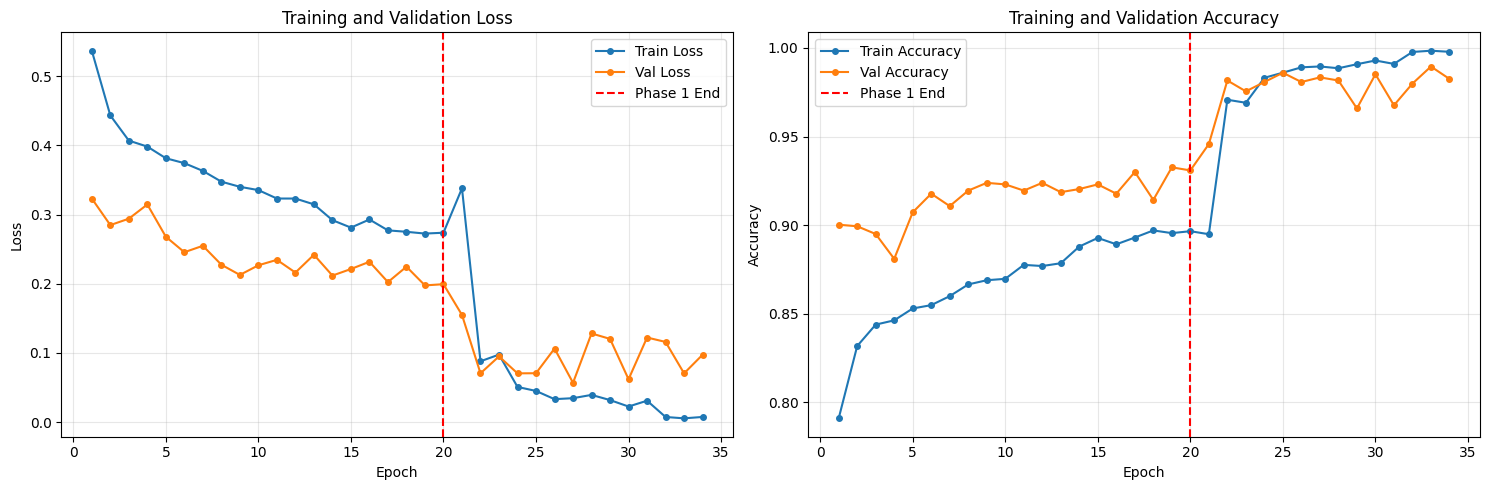

Training history plotted and saved


In [14]:
# Convert history to DataFrame
history_df = pd.DataFrame(history)

# Create training history plots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot loss
axes[0].plot(history_df['epoch'], history_df['train_loss'], label='Train Loss', marker='o', markersize=4)
axes[0].plot(history_df['epoch'], history_df['val_loss'], label='Val Loss', marker='o', markersize=4)

# Add vertical line at phase boundary
phase1_end = len([x for x in history['phase'] if x == 1])
axes[0].axvline(x=phase1_end, color='r', linestyle='--', label='Phase 1 End')

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot accuracy
axes[1].plot(history_df['epoch'], history_df['train_acc'], label='Train Accuracy', marker='o', markersize=4)
axes[1].plot(history_df['epoch'], history_df['val_acc'], label='Val Accuracy', marker='o', markersize=4)
axes[1].axvline(x=phase1_end, color='r', linestyle='--', label='Phase 1 End')

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('resnet50_training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print('Training history plotted and saved')

In [15]:
def evaluate_model(model, test_loader, device):
    """
    Evaluate model on test set and return predictions and labels
    """
    model.eval()
    
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())
    
    return np.array(all_preds), np.array(all_labels), np.array(all_probs)

# Get predictions on test set
print('Evaluating model on test set...')
test_preds, test_labels_array, test_probs = evaluate_model(model, test_loader, device)

# Calculate metrics
test_accuracy = accuracy_score(test_labels_array, test_preds)
precision, recall, f1, _ = precision_recall_fscore_support(test_labels_array, test_preds, average='weighted')

print('Test Set Results:')
print(f'Accuracy: {test_accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-Score: {f1:.4f}')
print()

# Per-class metrics
print('Per-Class Metrics:')
class_report = classification_report(test_labels_array, test_preds, target_names=class_names, digits=4)
print(class_report)

Evaluating model on test set...
Test Set Results:
Accuracy: 0.9847
Precision: 0.9848
Recall: 0.9847
F1-Score: 0.9847

Per-Class Metrics:
              precision    recall  f1-score   support

      glioma     0.9867    0.9867    0.9867       300
  meningioma     0.9833    0.9641    0.9736       306
     notumor     0.9901    0.9926    0.9914       405
   pituitary     0.9770    0.9933    0.9851       300

    accuracy                         0.9847      1311
   macro avg     0.9843    0.9842    0.9842      1311
weighted avg     0.9848    0.9847    0.9847      1311



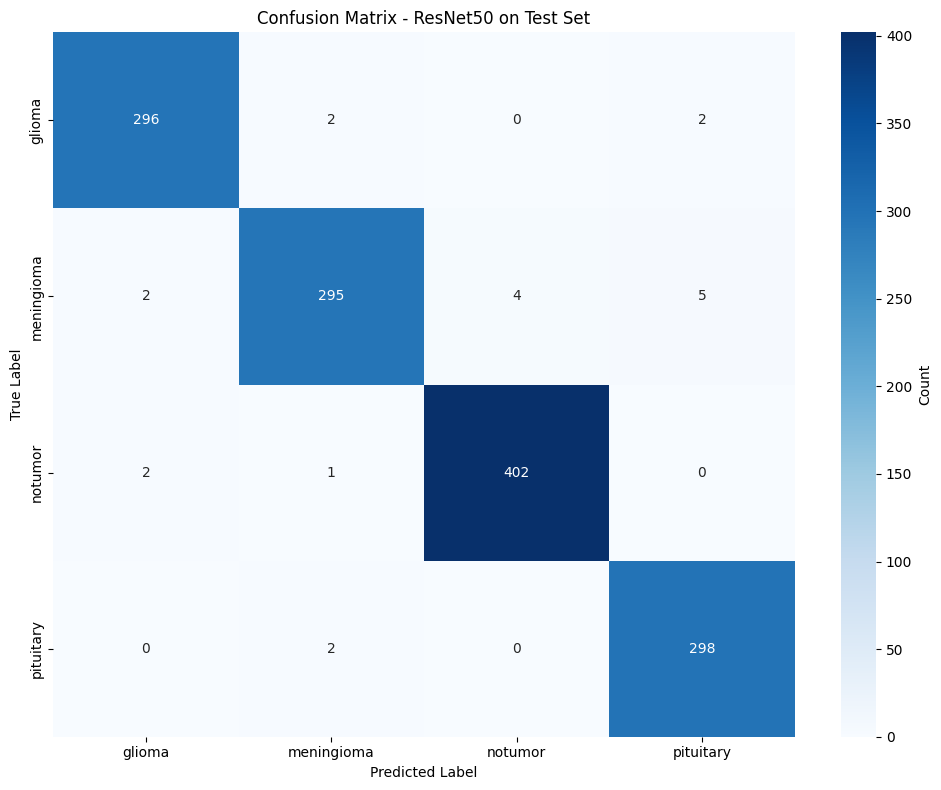

Per-Class Accuracy:
glioma: 0.9867
meningioma: 0.9641
notumor: 0.9926
pituitary: 0.9933


In [16]:
# Calculate confusion matrix
cm = confusion_matrix(test_labels_array, test_preds)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - ResNet50 on Test Set')
plt.tight_layout()
plt.savefig('resnet50_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Calculate per-class accuracy
per_class_acc = cm.diagonal() / cm.sum(axis=1)
print('Per-Class Accuracy:')
for i, class_name in enumerate(class_names):
    print(f'{class_name}: {per_class_acc[i]:.4f}')

In [17]:
pip install thop

Note: you may need to restart the kernel to use updated packages.


In [18]:
from thop import profile

def calculate_efficiency_metrics(model, device, input_size=(1, 3, 256, 256)):
    """
    Calculate comprehensive efficiency metrics
    """
    model.eval()
    
    # Total parameters
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    # Model size in MB
    param_size = sum(p.numel() * p.element_size() for p in model.parameters())
    buffer_size = sum(b.numel() * b.element_size() for b in model.buffers())
    model_size_mb = (param_size + buffer_size) / (1024 ** 2)
    
    # FLOPs calculation
    dummy_input = torch.randn(input_size).to(device)
    flops, params_thop = profile(model, inputs=(dummy_input,), verbose=False)
    flops_gflops = flops / 1e9
    
    # Inference time and FPS
    num_warmup = 10
    num_iterations = 100
    
    # Warmup
    with torch.no_grad():
        for _ in range(num_warmup):
            _ = model(dummy_input)
    
    # Synchronize GPU
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    
    # Measure inference time
    start_time = time.time()
    with torch.no_grad():
        for _ in range(num_iterations):
            _ = model(dummy_input)
    
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    
    end_time = time.time()
    
    avg_time_per_image = ((end_time - start_time) / num_iterations) * 1000
    fps = 1000 / avg_time_per_image
    
    # GPU memory usage
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        
        with torch.no_grad():
            _ = model(dummy_input)
        
        gpu_memory_mb = torch.cuda.max_memory_allocated() / (1024 ** 2)
    else:
        gpu_memory_mb = 0
    
    metrics = {
        'Total Parameters': total_params,
        'Trainable Parameters': trainable_params,
        'Model Size (MB)': model_size_mb,
        'FLOPs (GFLOPs)': flops_gflops,
        'Inference Time (ms)': avg_time_per_image,
        'FPS': fps,
        'GPU Memory (MB)': gpu_memory_mb
    }
    
    return metrics

# Calculate efficiency metrics
print('Calculating efficiency metrics...')
efficiency_metrics = calculate_efficiency_metrics(model, device)

print('\nEfficiency Metrics:')
print(f"Total Parameters: {efficiency_metrics['Total Parameters']:,}")
print(f"Trainable Parameters: {efficiency_metrics['Trainable Parameters']:,}")
print(f"Model Size: {efficiency_metrics['Model Size (MB)']:.2f} MB")
print(f"FLOPs: {efficiency_metrics['FLOPs (GFLOPs)']:.2f} GFLOPs")
print(f"Inference Time: {efficiency_metrics['Inference Time (ms)']:.2f} ms per image")
print(f"FPS: {efficiency_metrics['FPS']:.2f}")
print(f"GPU Memory Usage: {efficiency_metrics['GPU Memory (MB)']:.2f} MB")

Calculating efficiency metrics...

Efficiency Metrics:
Total Parameters: 24,033,604
Trainable Parameters: 24,033,604
Model Size: 91.88 MB
FLOPs: 5.40 GFLOPs
Inference Time: 6.48 ms per image
FPS: 154.43
GPU Memory Usage: 513.52 MB


In [19]:
# Create results dictionary
results = {
    'model_name': 'ResNet50',
    'test_accuracy': test_accuracy,
    'precision': precision,
    'recall': recall,
    'f1_score': f1,
    'per_class_accuracy': {class_names[i]: per_class_acc[i] for i in range(len(class_names))},
    **efficiency_metrics
}

# Save results to CSV
results_df = pd.DataFrame([results])
results_df.to_csv('resnet50_results.csv', index=False)
print('Results saved to resnet50_results.csv')

# Save training history
history_df.to_csv('resnet50_training_history.csv', index=False)
print('Training history saved to resnet50_training_history.csv')

# Save model
torch.save({
    'model_state_dict': model.state_dict(),
    'class_names': class_names,
    'label_encoder': label_encoder,
    'results': results,
    'history': history
}, 'resnet50_brain_tumor_model.pth')
print('Model saved to resnet50_brain_tumor_model.pth')

print('\nAll results and model saved successfully')

Results saved to resnet50_results.csv
Training history saved to resnet50_training_history.csv
Model saved to resnet50_brain_tumor_model.pth

All results and model saved successfully


In [20]:
# Create comprehensive summary table for thesis
summary_data = {
    'Metric': [
        'Test Accuracy',
        'Precision',
        'Recall',
        'F1-Score',
        'Total Parameters',
        'Model Size (MB)',
        'FLOPs (GFLOPs)',
        'Inference Time (ms)',
        'FPS',
        'GPU Memory (MB)'
    ],
    'Value': [
        f'{test_accuracy:.4f}',
        f'{precision:.4f}',
        f'{recall:.4f}',
        f'{f1:.4f}',
        f"{efficiency_metrics['Total Parameters']:,}",
        f"{efficiency_metrics['Model Size (MB)']:.2f}",
        f"{efficiency_metrics['FLOPs (GFLOPs)']:.2f}",
        f"{efficiency_metrics['Inference Time (ms)']:.2f}",
        f"{efficiency_metrics['FPS']:.2f}",
        f"{efficiency_metrics['GPU Memory (MB)']:.2f}"
    ]
}

summary_df = pd.DataFrame(summary_data)
print('ResNet50 Baseline Summary for Thesis:')
print(summary_df.to_string(index=False))

# Save summary
summary_df.to_csv('resnet50_summary_table.csv', index=False)
print('\nSummary table saved to resnet50_summary_table.csv')

ResNet50 Baseline Summary for Thesis:
             Metric      Value
      Test Accuracy     0.9847
          Precision     0.9848
             Recall     0.9847
           F1-Score     0.9847
   Total Parameters 24,033,604
    Model Size (MB)      91.88
     FLOPs (GFLOPs)       5.40
Inference Time (ms)       6.48
                FPS     154.43
    GPU Memory (MB)     513.52

Summary table saved to resnet50_summary_table.csv
